# The bells of Haarlem: analyzing a soundscape with ambiscape

Every evening at nine, two bells — the *Damiaatjes* — ring from the tower of
the Grote Kerk in Haarlem for exactly half an hour, a tradition that goes
back to the crusades. This notebook takes one evening's recording
(2026-07-17, a 4-channel *ambisonic* recording that captures the full 3D
sound field) and asks musical questions of it:

1. **What does the soundscape sound like overall?** (`analyze`)
2. **What notes does the city hum in?** (`tonality`)
3. **How fast does it pulse?** (`modspec`)
4. **What exactly is the bells' rhythm — and how much does it vary?**
   (`rhythm`)

Each question is one command in the
[ambiscape](https://github.com/fourMs/ambiscape) toolbox. You need
`pip install ambiscape` and the recording `260717_001.WAV` in this folder
(it is not in the git repository — see the README).

In [1]:
import json
from IPython.display import Image
import ambiscape as asc
from ambiscape import features, analysis, rhythm, modulation, tonality

sess = asc.open_session(".")     # reads the WAV's embedded clock + our
take = sess.takes[0]             # calibration.json clock correction
print(f"{take.path.name}: starts {sess.clock(take.start)}, "
      f"{take.duration/60:.1f} minutes")

260717_001.WAV: starts 17 Jul 21:08:54, 24.5 minutes


## 1. The soundscape at a glance

`analyze` reads the whole file once and computes everything per second:
loudness, spectrum, where sound comes from (this is what the four ambisonic
channels buy us), and how *diffuse* it is. The descriptors below summarize
the session; the overview figure is the soundscape's "score".

A few worth reading like a musician: `dynamics_L10_L90` says how far loud
moments sit above quiet ones (4.5 dB = remarkably steady — the bells never
stop); `azimuth_R` near 1 means the sound comes from one direction; and the
`fg_fraction` says how much of the sound sits *above* its own background —
foreground versus accompaniment.

In [2]:
paths = features.extract_session(sess, "analysis/features")
F = features.load_features(paths)
summary = analysis.summarize(F)
from ambiscape.background import summarize_foreground
summary.update(summarize_foreground(F))
summary

{'duration_min': 24.5,
 'leq_dbfs': -38.6,
 'laeq_dbfs': -40.1,
 'leq_minus_laeq_db': 1.5,
 'L10': -40.9,
 'L50': -43.7,
 'L90': -45.4,
 'dynamics_L10_L90': 4.5,
 'events_per_min': 1.3,
 'event_median_dur_s': 0.25,
 'centroid_median_hz': 532,
 'flatness_median': 0.007,
 'diffuseness_median': 0.63,
 'diffuseness_iqr': 0.12,
 'azimuth_mean_deg': 52.0,
 'azimuth_R': 0.95,
 'azimuth_fg_deg': 55.0,
 'elevation_fg_median_deg': -3.0,
 'n_events': 31,
 'fg_fraction_median': 0.51,
 'fg_fraction_p90': 0.88,
 'spectral_events_per_min': 35.7,
 'spectral_event_median_dur_s': 3.0}

/home/alexanje/github/ambiscape/src/ambiscape/figures.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.985))


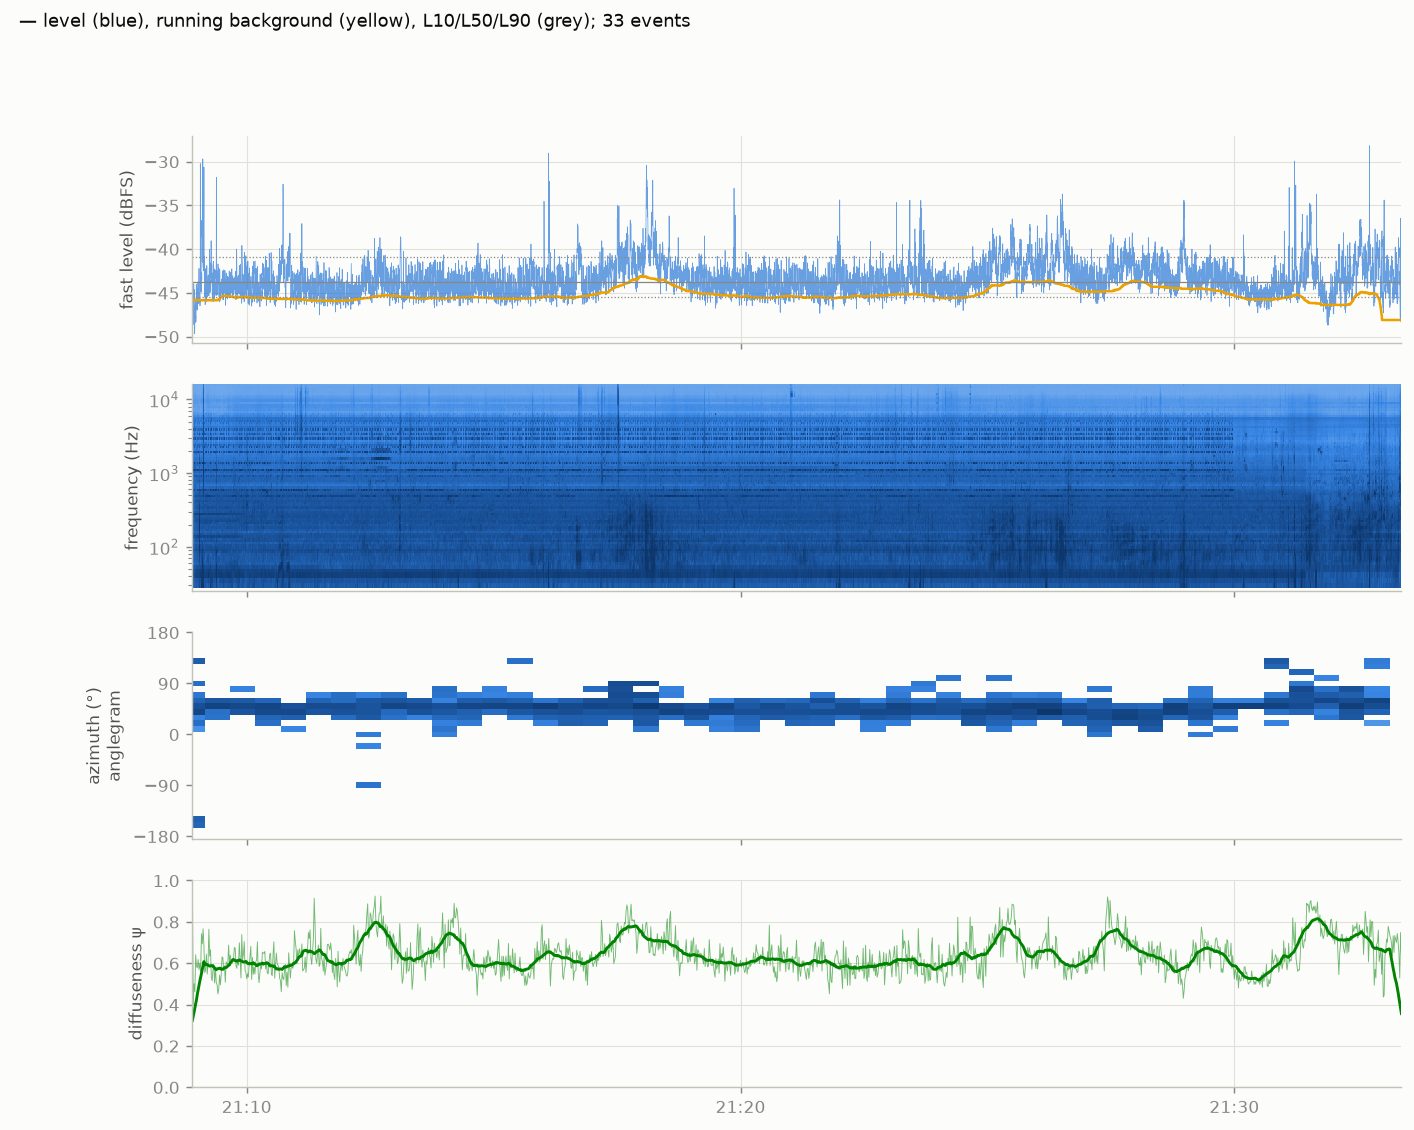

In [3]:
from ambiscape import figures
figures.overview(F, "analysis/overview.png", title=sess.name,
                 clock=sess.clock)
Image("analysis/overview.png", width=900)

## 2. What notes does the city hum in?

`tonality` finds every steady pitched component minute by minute — bell
partials, machine hums — links them into *tracks*, and folds their energy
onto the 12 pitch classes. It also runs a **harmonic sieve**: voices and
engines have harmonic overtones (2×, 3×, 4× a fundamental), but bells do
not — their partials follow the minor-third bell recipe (1 : 2 : 2.4 : 3 :
4). So *low harmonicity* here is the fingerprint of bells.

Look at the pitch-class profile: the city hums in **B♭ and D** — the two
bells' strike notes — with C♯ (bell A's *tierce*, the partial that gives a
bell its minor-third color) and F (its *quint*) next.

top pitch classes: D, A#, C#
inharmonicity (1 = nothing harmonic about it): 0.527
longest tonal tracks:
   2871.1 Hz  minutes 0-23  +24.2 dB
    597.7 Hz  minutes 0-21  +14.2 dB
   1910.2 Hz  minutes 0-21  +22.4 dB
   2302.7 Hz  minutes 0-21  +19.2 dB
   3369.1 Hz  minutes 0-21  +15.6 dB
   3966.8 Hz  minutes 0-21  +20.7 dB


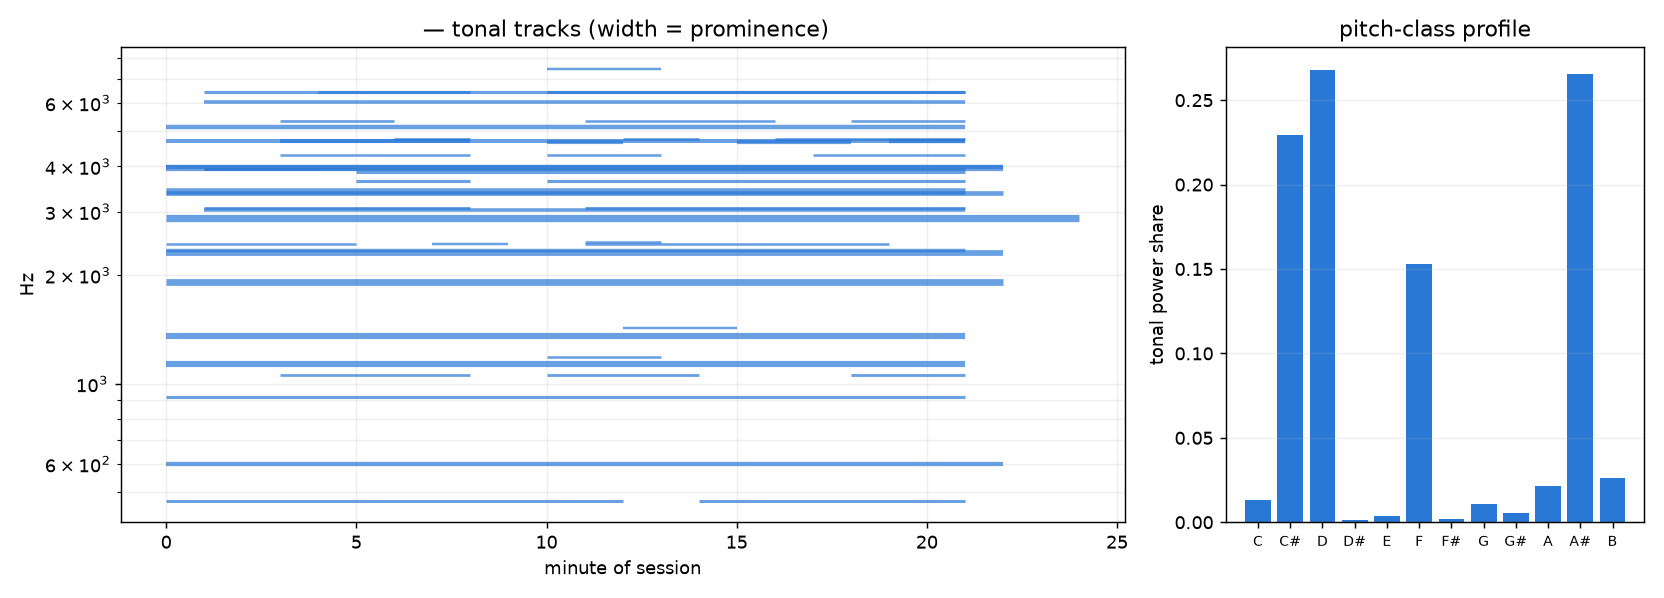

In [4]:
ton = tonality.run_session(sess, "analysis")
print("top pitch classes:", ", ".join(ton["top_pitch_classes"]))
print("inharmonicity (1 = nothing harmonic about it):",
      ton["inharmonicity_median"])
print("longest tonal tracks:")
for tr in ton["tracks"][:6]:
    print(f"  {tr['f_median_hz']:7.1f} Hz  minutes {tr['t0_min']}-"
          f"{tr['t1_min']}  +{tr['prominence_db']} dB")
Image("analysis/tonality.png", width=900)

## 3. How fast does the soundscape pulse?

Rhythm exists at every time scale. `modspec` measures the *modulation
spectrum* of the loudness envelope in three bands: **micro** (0.5–20 Hz —
strike rates, speech rates), **meso** (2–100 s periods — traffic waves),
and **macro** (minutes — things switching on and off).

The micro peak lands at ~0.6 Hz: the bells strike about every 1.7 s on
average. The macro peak reflects the biggest event of the session — the
ringing stopping at 21:30.

micro  peak: every 1.71 s (depth 0.897)
meso   peak: every 100.0 s (depth 0.198)
macro  peak: every 286.43 s (depth 0.276)


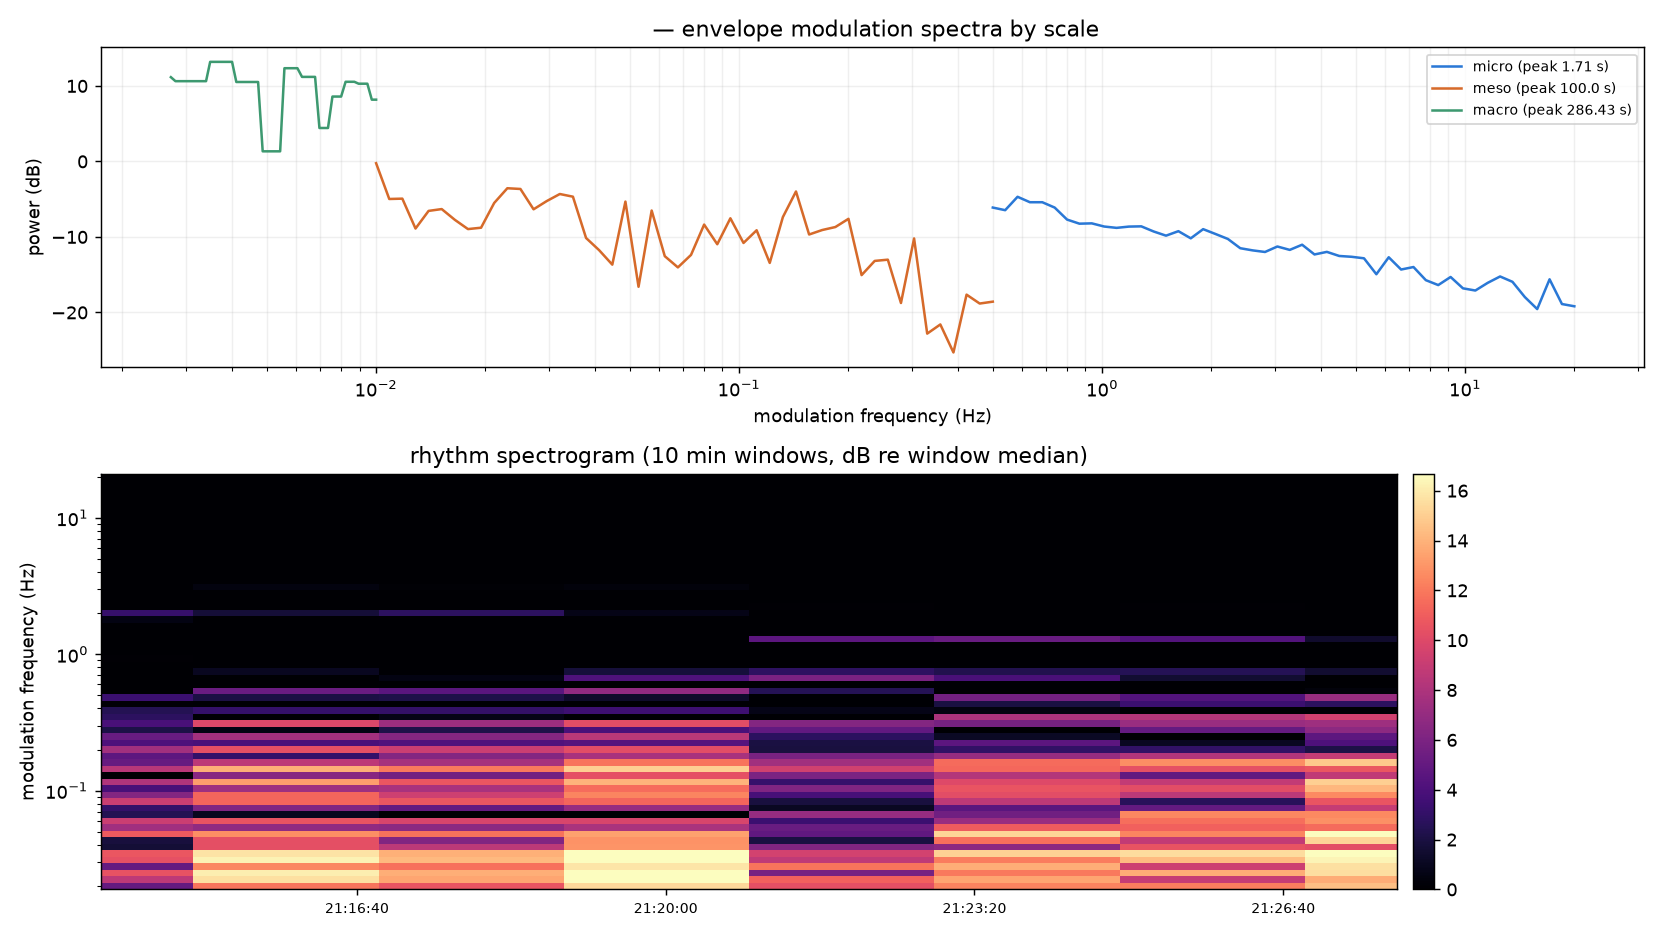

In [5]:
prof = modulation.run_session(sess, "analysis")
for scale, st in prof["scales"].items():
    print(f"{scale:6s} peak: every {st['peak_period_s']} s "
          f"(depth {st['modulation_depth']})")
Image("analysis/modulation_profile.png", width=900)

## 4. The bells' rhythm — repetition with variation

`rhythm` zooms into strike level: it finds each bell's partials, separates
the two bells, detects every strike, and measures the cycle. Read the
output like this:

- both "sources" have the **same period, 3.1669 s** — a shared clock;
- `phase_stats` gives circular statistics: R near 1 means the strikes sit
  at fixed positions in the cycle (all Rayleigh p-values are essentially
  zero — this rhythm could not be chance);
- `phase_lock` is the punchline: bell B strikes at a fixed 1.63 s after
  bell A with R = 0.997 — **the two bells are mechanically locked**, not
  two independent swinging pendulums;
- `crosstalk_suspects` marks detected "strikes" that are really the other
  bell bleeding into the analysis — always check before over-interpreting.

The full pattern is three strikes per cycle — long, short, long
(1.37 / 0.42 / 1.38 s), melodically **B♭ … D–B♭** — repeated ~400 times.
Almost all cycle-to-cycle looseness comes from one position: bell A's
backswing strike. Repetition with variation, localized in a single
clapper.

  active section ends at 1266 s
  23 partials (475-4312 Hz)


source A: period 3.1669 s, 886 strikes, strike positions [0.99, 0.65, 0.51, 0.33]
source B: period 3.1669 s, 770 strikes, strike positions [0.99, 0.49]

phase lock: {'B_vs_A': {'mean_offset_cycles': 0.513, 'mean_offset_s': 1.6245, 'R': 0.9968, 'circ_sd_s': 0.0406, 'n': 390}}
cross-talk suspects: {'A0': 0.6, 'B1': 0.65}


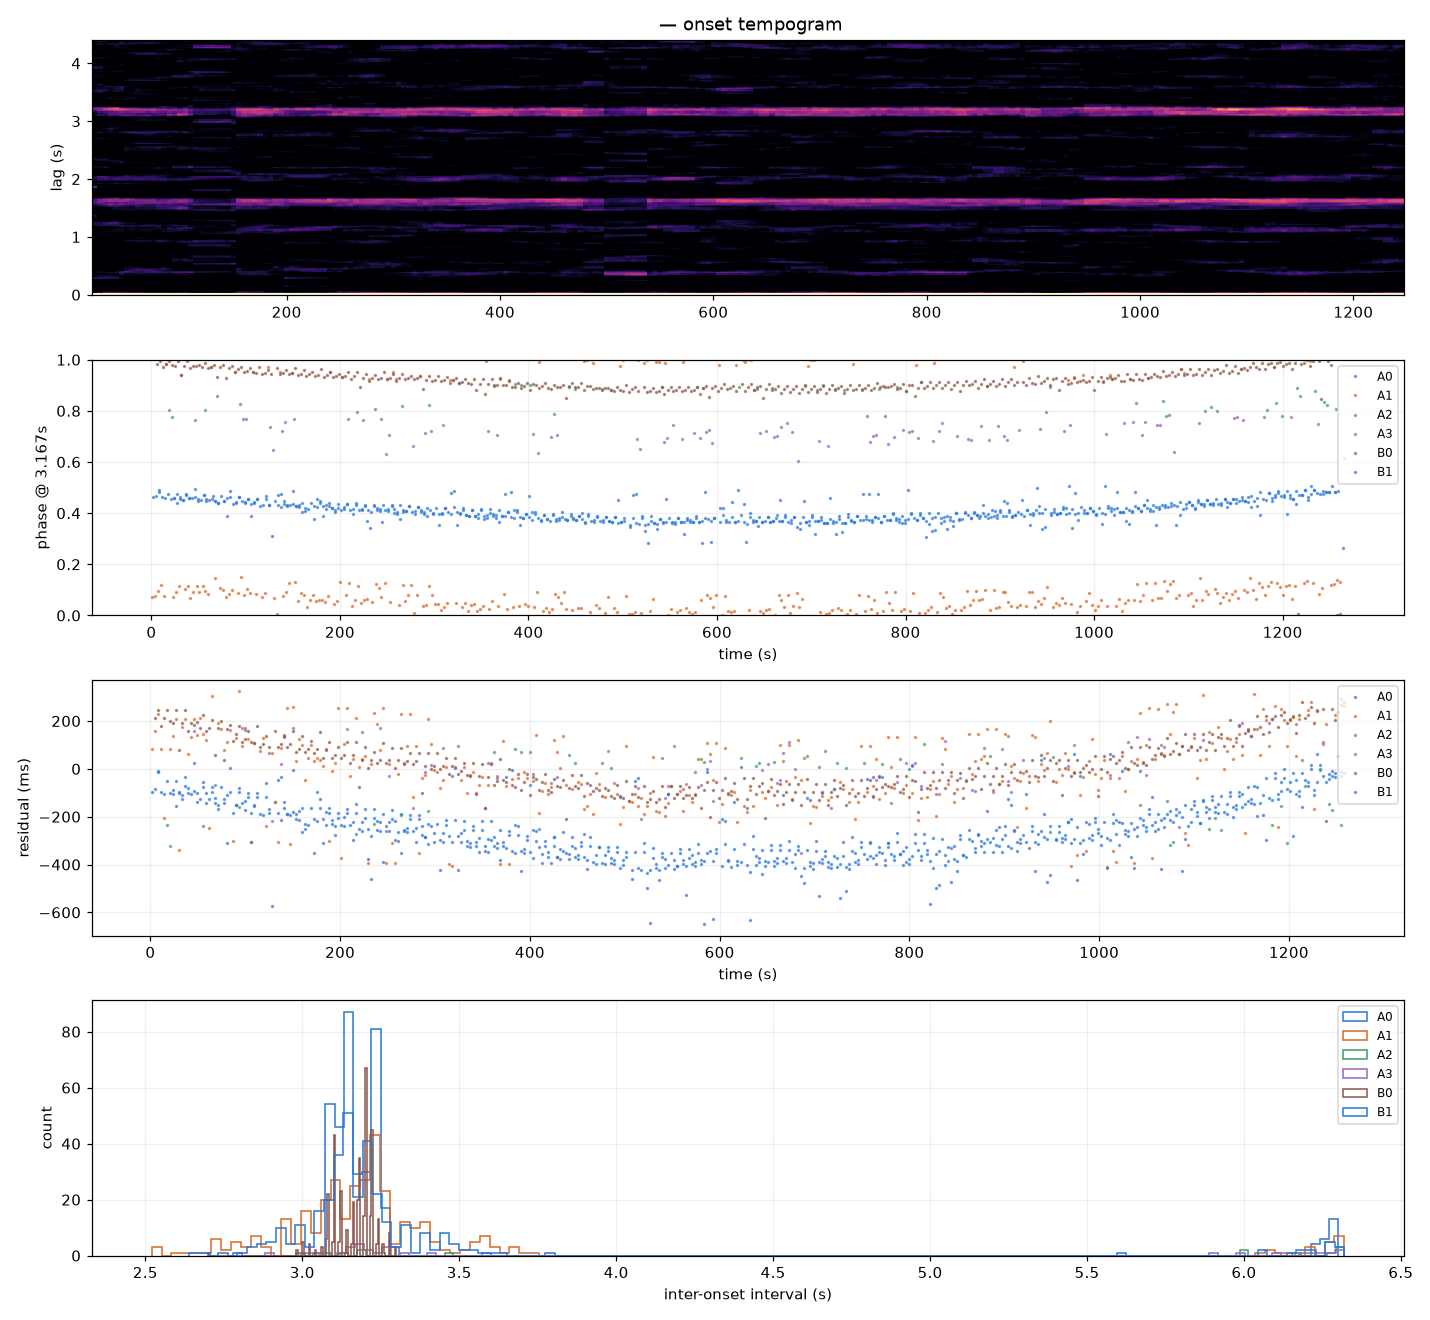

In [6]:
res = rhythm.run_session(sess, "analysis")
for src in res["sources"]:
    print(f"source {src['name']}: period {src['period_s']} s, "
          f"{src['n_strikes']} strikes, "
          f"strike positions {src['phase_clusters']}")
print("\nphase lock:", res["phase_lock"])
print("cross-talk suspects:", res.get("crosstalk_suspects"))
Image("analysis/rhythm_overview.png", width=900)

## Where to go from here

- `RHYTHM_REPORT.md` in this folder — the full technical report, including
  timbre (why the hum partial turns the pattern into a continuous drone)
  and the Schafer/Schaeffer soundscape taxonomy;
- `blog-damiaatjes.md` — the story, history included;
- the [ambiscape documentation](https://fourms.github.io/ambiscape/) and
  [wiki](https://github.com/fourMs/ambiscape/wiki) — including the
  case-study page distilled from this very session;
- try these commands on your own recording: any WAV folder with embedded
  timestamps is a session. `ambiscape analyze`, then ask your questions.